# Lab 02 — คณิตศาสตร์พื้นฐานด้วย numpy
### Math prerequisites: functions, activations, derivatives, computational graph

**กลุ่ม:** A พื้นฐาน · **อ่านคู่กับสไลด์หน้า:** 2-12, 22-24 · **เวลาโดยประมาณ:** 60 นาที · **Dataset:** ไม่ใช้

**ควรทำมาก่อน:** Lab 01 (shape, vectorization)

## จุดประสงค์การเรียนรู้
เมื่อทำ lab นี้จบ นิสิตจะสามารถ
1. อธิบายได้ว่า function คืออะไร (หนึ่ง input → หนึ่ง output) และเขียน function เป็นโค้ด Python ที่รับ array ได้
2. วาดกราฟ sigmoid / tanh / ReLU และบอกคุณสมบัติได้: ช่วงค่า, เกือบเป็นเส้นตรงใกล้ 0, saturation เมื่อ |x| ใหญ่
3. หาอนุพันธ์เชิงตัวเลขด้วยการ "nudge" $\Delta x$ ตามสไลด์ p.9 และเข้าใจว่าทำไม $\Delta x$ เล็กแล้วแม่นขึ้น
4. ตรวจสอบสูตรอนุพันธ์ $g(1-g)$, $1-\tanh^2$ และ step function ของ ReLU ด้วยตัวเลขจริง
5. เดิน computational graph ของ $J = 3(a + bc)$ ทั้ง forward และ backward ด้วย chain rule ได้ตัวเลข 3, 6, 9

> **วิธีใช้ notebook นี้:** อ่าน markdown cell ก่อน แล้วรัน code cell ถัดไปด้วย `Shift+Enter` ทีละ cell ตามลำดับ
> ทุก code cell มีคำอธิบายว่าทำอะไรและทำไม ถ้าอยากทดลอง ให้แก้ตัวเลขใน cell แล้วรันซ้ำได้เลย

## เตรียมเครื่องมือ
cell แรกของทุก lab จะ import library ที่ใช้ และตั้ง **seed** ให้ตัวเลขสุ่มเหมือนกันทุกครั้งที่รัน
(ไม่งั้นค่าเริ่มต้นของ weight จะต่างกันทุกรอบ และตัวเลขในหน้าจอจะไม่ตรงกับคำอธิบาย)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import nnlab                      # package ประกอบ lab (ติดตั้งแล้วด้วย uv sync)
except ImportError:                   # เผื่อเปิดด้วย kernel อื่น: เพิ่ม lab/src เข้า path เอง
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
    import nnlab

from nnlab.utils import set_seed

rng = set_seed(463)                   # 463 = เลขวิชา CP463
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
print("numpy", np.__version__, "| nnlab", nnlab.__version__)

numpy 2.2.6 | nnlab 0.1.0


## สัญลักษณ์ในบทนี้
| สัญลักษณ์ | ความหมาย | ใน numpy |
|---|---|---|
| $x \mapsto f(x)$ | function: ส่ง input $x$ ไปเป็น output $f(x)$ ค่าเดียว (p.3) | `def f(x): return ...` |
| $g(z)$ | activation function ที่รับ $z$ (ผลรวมถ่วงน้ำหนัก) (p.4-6) | `sigmoid(z)`, `np.tanh(z)`, `np.maximum(0, z)` |
| $f'(x) = \dfrac{df}{dx}$ | อนุพันธ์ = ความชันของ $f$ ที่จุด $x$ (p.9) | `(f(x + dx) - f(x)) / dx` |
| $\Delta x$ | ระยะ "nudge" เล็กๆ เช่น 0.001 | `dx = 1e-3` |
| $\dfrac{dJ}{da} = \dfrac{dJ}{dv}\cdot\dfrac{dv}{da}$ | chain rule: คูณความชันต่อกันตามเส้นทางใน graph (p.24) | คูณตัวเลขทีละขั้น |

## ขั้นที่ 1 · function คืออะไร (สไลด์ p.3)
**function** คือกฎที่รับ input หนึ่งค่าแล้วให้ output **หนึ่งค่าเท่านั้น** — สไลด์เขียนว่า $x \mapsto f(x)$
ทำไมต้องย้ำเรื่องนี้? เพราะ neural network ทั้งก้อนคือ function ขนาดใหญ่ตัวเดียว (input = ข้อมูล, output = คำทำนาย)
และทุกอย่างที่เราจะทำในคอร์ส (หาอนุพันธ์, gradient descent) ตั้งอยู่บนสมบัติ "หนึ่ง input → หนึ่ง output" นี้

ใน Python เราเขียน function ด้วย `def` และถ้าข้างในใช้เฉพาะตัวดำเนินการของ numpy
function เดียวกันจะรับได้ทั้งตัวเลขเดียวและ array ทั้งก้อน (vectorization จาก lab01) — คาดว่าจะเห็น $f(2) = 4$, $f(3) = 9$ และ array ยกกำลังสองทีละตัว

In [2]:
def f(x):
    """f(x) = x²  — ตัวอย่างในสไลด์ p.9"""
    return x ** 2

print("f(2) =", f(2), "| f(3) =", f(3))

xs = np.array([-2.0, -1.0, 0.0, 1.0, 2.0, 3.0])     # xs: (6,)
print("xs   =", xs)
print("f(xs)=", f(xs), " ← function เดียวกัน ใช้กับ array ทั้งก้อนได้เลย")

f(2) = 4 | f(3) = 9
xs   = [-2. -1.  0.  1.  2.  3.]
f(xs)= [4. 1. 0. 1. 4. 9.]  ← function เดียวกัน ใช้กับ array ทั้งก้อนได้เลย


สไลด์ p.3 มีรูปขวาที่เขียนว่า "This is NOT a function" — ตัวอย่างคือความสัมพันธ์ $y^2 = x$
ถ้าให้ $x = 4$ จะได้ $y = 2$ **และ** $y = -2$ สอง output → ไม่ใช่ function
วิธีตรวจง่ายๆ คือ **vertical line test**: ลากเส้นตั้งที่ $x$ ใดๆ ถ้าตัดกราฟมากกว่า 1 จุด แสดงว่าไม่ใช่ function

สังเกตว่า `np.sqrt` คืนค่าเฉพาะรากบวก — numpy "เลือก" กิ่งเดียวเพื่อให้มันเป็น function ได้
cell นี้แสดงสองคำตอบของ $y^2 = 4$ และวาดรูปเทียบกันสองข้าง

y² = 4.0 มีคำตอบ y = [ 2. -2.] ← สอง output สำหรับ input เดียว → ไม่ใช่ function
np.sqrt(4) = 2.0 ← numpy เลือกเฉพาะรากบวก จึงเป็น function


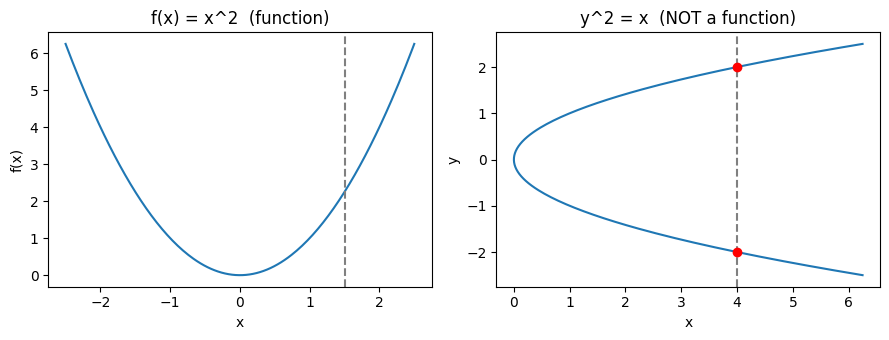

In [3]:
x0 = 4.0
roots = np.roots([1, 0, -x0])                      # แก้ y² - 4 = 0 → roots: (2,)
print(f"y² = {x0} มีคำตอบ y =", roots, "← สอง output สำหรับ input เดียว → ไม่ใช่ function")
print("np.sqrt(4) =", np.sqrt(x0), "← numpy เลือกเฉพาะรากบวก จึงเป็น function")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
xs = np.linspace(-2.5, 2.5, 200)                  # xs: (200,)
axes[0].plot(xs, f(xs)); axes[0].axvline(1.5, color="gray", ls="--")
axes[0].set_title("f(x) = x^2  (function)"); axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")

ys = np.linspace(-2.5, 2.5, 200)                  # วาด x = y² โดยให้ y เป็นตัวแปรอิสระ
axes[1].plot(ys ** 2, ys); axes[1].axvline(x0, color="gray", ls="--")
axes[1].scatter([x0, x0], roots, color="red", zorder=3)
axes[1].set_title("y^2 = x  (NOT a function)"); axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.tight_layout(); plt.show()

## ขั้นที่ 2 · activation functions (สไลด์ p.4-6)
ใน perceptron และ neural network เราจะรวม input ถ่วงน้ำหนักได้ค่า $z$ แล้วส่ง $z$ ผ่าน **activation function** $g(z)$
เพื่อบีบให้อยู่ในช่วงที่ต้องการ (เช่นความน่าจะเป็น 0-1) หรือเพื่อใส่ความ "ไม่เป็นเส้นตรง" เข้าไป สไลด์ให้มา 3 ตัว

| | sigmoid (p.4) | tanh (p.5) | ReLU (p.6) |
|---|---|---|---|
| สูตร | $g(z) = \dfrac{1}{1 + e^{-z}}$ | $g(z) = \tanh(z) = \dfrac{e^z - e^{-z}}{e^z + e^{-z}}$ | $g(z) = \max(0, z)$ |
| ช่วงค่า output | $(0, 1)$ | $(-1, 1)$ | $[0, \infty)$ |
| ใกล้ $z = 0$ | เกือบเป็นเส้นตรง | เกือบเป็นเส้นตรง | เส้นตรงชัน 1 ทางขวา |
| saturation | $\lvert z\rvert > 4$ เปลี่ยนช้ามาก | $\lvert z\rvert > 2$ เปลี่ยนช้ามาก | ไม่ saturate ทางขวา; $z \le 0$ ให้ 0 |

เราเขียนทั้งสามด้วย numpy ตรงตามสูตร แล้วลองแทนค่า $z = -4, -2, 0, 2, 4$ — คาดว่า sigmoid(0) = 0.5, tanh(0) = 0, ReLU ตัดค่าลบเป็น 0

In [4]:
def sigmoid_naive(z):
    """g(z) = 1 / (1 + e^{-z})  เขียนตรงตามสูตร p.4"""
    return 1.0 / (1.0 + np.exp(-z))

def tanh(z):
    return np.tanh(z)                                  # numpy มีให้แล้ว (สูตร p.5)

def relu(z):
    return np.maximum(0.0, z)                          # max(0, z) ทีละตัว (p.6)

z = np.array([-4.0, -2.0, 0.0, 2.0, 4.0])              # z: (5,)
print("z          =", z)
print("sigmoid(z) =", sigmoid_naive(z))
print("tanh(z)    =", tanh(z))
print("relu(z)    =", relu(z))

z          = [-4. -2.  0.  2.  4.]
sigmoid(z) = [0.018  0.1192 0.5    0.8808 0.982 ]
tanh(z)    = [-0.9993 -0.964   0.      0.964   0.9993]
relu(z)    = [0. 0. 0. 2. 4.]


### ปัญหา overflow ของ sigmoid และวิธีแก้
ตัวเลขทศนิยมในคอมพิวเตอร์มีขีดจำกัด: `np.exp(1000)` ใหญ่เกิน float64 จึงกลายเป็น `inf` พร้อม `RuntimeWarning`
ถ้าเราแทน $z = -1000$ ในสูตร $1/(1 + e^{-z})$ จะเจอ $e^{1000}$ พอดี — ผลลัพธ์ยังถูก (1/inf = 0) แต่ warning จะรกหน้าจอตอนเทรน และในบางกรณีกลายเป็น `nan`

วิธีแก้: ใช้รูปที่เท่ากันทางคณิตศาสตร์แต่เลขชี้กำลังไม่เป็นบวก — สังเกตว่า $e^{-|z|} \le 1$ เสมอ
- ถ้า $z \ge 0$: $g(z) = \dfrac{1}{1 + e^{-|z|}}$
- ถ้า $z < 0$: $g(z) = \dfrac{e^{-|z|}}{1 + e^{-|z|}}$ (คูณเศษและส่วนด้วย $e^{z}$)

cell นี้ดัก warning ไว้ให้เห็นก่อน แล้วเขียน `sigmoid` แบบ stable ที่ให้ค่าเท่ากันแต่ไม่มี warning (ตรวจด้วย `np.allclose`)

In [5]:
import warnings

z_big = np.array([-1000.0, -10.0, 0.0, 10.0, 1000.0])  # z_big: (5,)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    with np.errstate(over="warn"):                     # ให้ numpy เตือนเมื่อ overflow
        out_naive = sigmoid_naive(z_big)
print("sigmoid_naive(z_big) =", out_naive)
for w in caught:
    print("   →", w.category.__name__, ":", w.message)

def sigmoid(z):
    """sigmoid แบบ numerically stable — ค่าเท่า sigmoid_naive ทุกจุด แต่ไม่ overflow"""
    z = np.asarray(z, dtype=float)
    e = np.exp(-np.abs(z))                             # เลขชี้กำลัง ≤ 0 → ไม่มีทาง overflow
    return np.where(z >= 0, 1.0 / (1.0 + e), e / (1.0 + e))

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    out_stable = sigmoid(z_big)
print("sigmoid(z_big)       =", out_stable, "| warnings:", len(caught))
assert np.allclose(sigmoid(z), sigmoid_naive(z))       # ค่าเท่ากันในช่วงปกติ
print("sigmoid(0) =", sigmoid(0.0), "(ต้องเป็น 0.5)")

sigmoid_naive(z_big) = [0.  0.  0.5 1.  1. ]
   → RuntimeWarning : overflow encountered in exp
sigmoid(z_big)       = [0.  0.  0.5 1.  1. ] | warnings: 0
sigmoid(0) = 0.5 (ต้องเป็น 0.5)


### วาดกราฟทั้งสามตัว
วาดบนช่วง $z \in [-6, 6]$ แถบสีเทาคือโซน **saturation** ที่สไลด์บอก ($|z| > 4$ สำหรับ sigmoid, $|z| > 2$ สำหรับ tanh)
สังเกต 3 อย่าง: (1) sigmoid อยู่ระหว่าง 0-1 และ tanh ระหว่าง -1 ถึง 1, (2) ตรงกลางทั้งคู่เกือบเป็นเส้นตรง,
(3) ReLU เป็นเส้นตรงหักมุมที่ 0 ไม่มีเพดานทางขวา

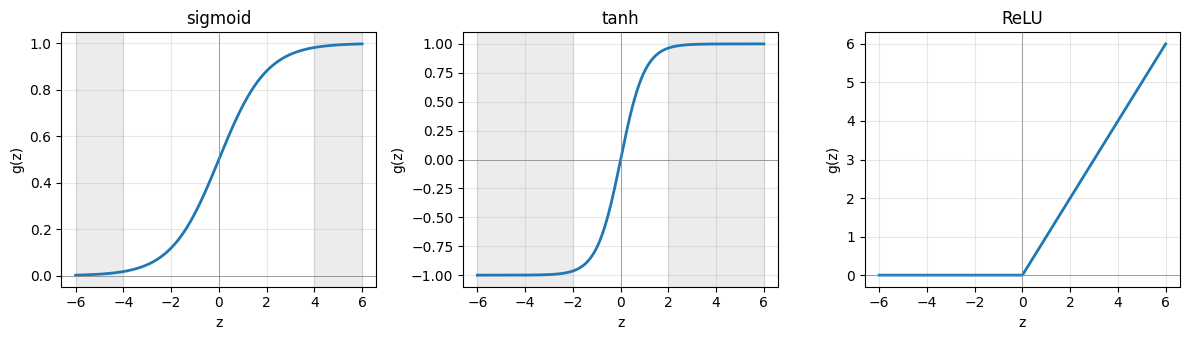

In [6]:
zs = np.linspace(-6, 6, 400)                           # zs: (400,)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (name, g, sat) in zip(axes, [("sigmoid", sigmoid, 4), ("tanh", tanh, 2), ("ReLU", relu, None)]):
    ax.plot(zs, g(zs), lw=2)
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
    if sat is not None:                                # แถบ saturation ตามสไลด์
        ax.axvspan(-6, -sat, color="gray", alpha=0.15); ax.axvspan(sat, 6, color="gray", alpha=0.15)
    ax.set_title(name); ax.set_xlabel("z"); ax.set_ylabel("g(z)"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### ตรวจคุณสมบัติในตารางด้วยตัวเลข
แทนที่จะเชื่อตาราง เราคำนวณสด: ค่าต่ำสุด/สูงสุดบน grid กว้าง, ความชันที่ $z = 0$ (ใช้การ nudge สองข้างเล็กน้อย — จะอธิบายละเอียดในขั้นที่ 3)
และ "saturation" วัดจากค่าที่เปลี่ยนไปเมื่อ $z$ เดินจาก 4 → 6 (sigmoid) หรือ 2 → 4 (tanh)
คาดว่า: ความชันที่ 0 ของ sigmoid ≈ 0.25, tanh ≈ 1 และการเปลี่ยนแปลงในโซน saturation น้อยกว่า 0.04
ส่วน ReLU ที่ 0 จริงๆ **ไม่นิยาม** (ซ้ายชัน 0 ขวาชัน 1) — การ nudge สองข้างจะได้ 0.5 ซึ่งเป็นแค่ค่าเฉลี่ยของสองฝั่ง ไม่ใช่ความชันจริง บรรทัดสุดท้ายของ cell แยกสองฝั่งให้ดู

In [7]:
z_wide = np.linspace(-50, 50, 10001)                   # z_wide: (10001,)
h = 1e-3
print(f"{'function':10s}{'min':>9s}{'max':>9s}{'slope@0':>10s}")
for name, g in [("sigmoid", sigmoid), ("tanh", tanh), ("relu", relu)]:
    vals = g(z_wide)
    slope0 = (g(h) - g(-h)) / (2 * h)                  # ความชันโดยประมาณที่ z = 0
    print(f"{name:10s}{vals.min():9.4f}{vals.max():9.4f}{slope0:10.4f}")

print("\nsaturation ของ sigmoid: g(4) = %.4f, g(6) = %.4f, เปลี่ยนแค่ %.4f" % (sigmoid(4.0), sigmoid(6.0), sigmoid(6.0) - sigmoid(4.0)))
print("saturation ของ tanh   : g(2) = %.4f, g(4) = %.4f, เปลี่ยนแค่ %.4f" % (tanh(2.0), tanh(4.0), tanh(4.0) - tanh(2.0)))
print("เทียบกับช่วงกลาง sigmoid: g(1) - g(-1) = %.4f" % (sigmoid(1.0) - sigmoid(-1.0)))
print("ReLU ที่ 0: ความชันซ้าย =", (relu(0.0) - relu(-h)) / h, "| ความชันขวา =", (relu(h) - relu(0.0)) / h, "← ไม่เท่ากัน จึงนิยามอนุพันธ์ที่ 0 ไม่ได้ (p.12)")

function        min      max   slope@0
sigmoid      0.0000   1.0000    0.2500
tanh        -1.0000   1.0000    1.0000
relu         0.0000  50.0000    0.5000

saturation ของ sigmoid: g(4) = 0.9820, g(6) = 0.9975, เปลี่ยนแค่ 0.0155
saturation ของ tanh   : g(2) = 0.9640, g(4) = 0.9993, เปลี่ยนแค่ 0.0353
เทียบกับช่วงกลาง sigmoid: g(1) - g(-1) = 0.4621
ReLU ที่ 0: ความชันซ้าย = 0.0 | ความชันขวา = 1.0 ← ไม่เท่ากัน จึงนิยามอนุพันธ์ที่ 0 ไม่ได้ (p.12)


## ขั้นที่ 3 · อนุพันธ์ด้วยการ nudge (สไลด์ p.9)
**อนุพันธ์** $f'(x)$ คือความชันของ $f$ ที่จุด $x$ — "ถ้าขยับ $x$ นิดเดียว $f$ จะเปลี่ยนเท่าไร" นิยามคือ
$$f'(x) = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}$$

เราไม่ต้องรู้แคลคูลัสก็คำนวณได้: แทน $\Delta x$ ด้วยเลขเล็กๆ เช่น 0.001 แล้วหารตรงๆ — สไลด์เรียกว่าการ **nudge**
ตัวอย่าง p.9: $f(x) = x^2$ ที่ $x = 2$ ได้ $f(2) = 4$ และ $f(2.001) \approx 4.004$ ดังนั้นความชัน $\approx 0.004 / 0.001 = 4$
ซึ่งตรงกับสูตรแคลคูลัส $\frac{d}{dx}x^2 = 2x = 4$

cell นี้เขียน `nudge(f, x, dx)` แล้วทำซ้ำตัวเลขสไลด์ — สังเกตว่าค่าจริงคือ 4.004001 และความชัน 4.001 (สไลด์ปัดเศษเป็น 4)

In [8]:
def nudge(f, x, dx=1e-3):
    """อนุพันธ์เชิงตัวเลขแบบ forward difference: (f(x+dx) - f(x)) / dx"""
    return (f(x + dx) - f(x)) / dx

x0, dx = 2.0, 1e-3
print(f"f({x0})      = {f(x0)}")
print(f"f({x0 + dx})  = {f(x0 + dx):.6f}")
print(f"Δf         = {f(x0 + dx) - f(x0):.6f}   (สไลด์ปัดเป็น 0.004)")
print(f"slope Δf/Δx = {nudge(f, x0, dx):.6f}   (สไลด์ปัดเป็น 4; ค่าจริงจากแคลคูลัส 2x = {2 * x0})")

f(2.0)      = 4.0
f(2.001)  = 4.004001
Δf         = 0.004001   (สไลด์ปัดเป็น 0.004)
slope Δf/Δx = 4.001000   (สไลด์ปัดเป็น 4; ค่าจริงจากแคลคูลัส 2x = 4.0)


ทำไมได้ 4.001 ไม่ใช่ 4 พอดี? เพราะ $\Delta x$ ยังไม่ใช่ศูนย์ — สำหรับ $f = x^2$ คำนวณได้ว่า
$\frac{(x+\Delta x)^2 - x^2}{\Delta x} = 2x + \Delta x$ ค่าที่เกินมาคือ $\Delta x$ พอดี
สไลด์ p.9 ยังวาดกรณี $\Delta x = 1$ ไว้ด้วย ซึ่งจะได้ $(9 - 4)/1 = 5$ ห่างจาก 4 มาก

cell นี้ลด $\Delta x$ ทีละ 10 เท่า — คาดว่าความคลาดเคลื่อนจะลดลง 10 เท่าตาม จนถึงจุดที่ทศนิยมของคอมพิวเตอร์เริ่มปัดเศษ

In [9]:
true_slope = 2 * x0
print(f"{'dx':>10s} {'slope':>12s} {'error':>12s}")
for dx in [1.0, 0.1, 0.01, 1e-3, 1e-4, 1e-6, 1e-8, 1e-12]:
    s = nudge(f, x0, dx)
    print(f"{dx:10.0e} {s:12.8f} {abs(s - true_slope):12.2e}")
print("\n→ dx เล็กลง error เล็กลงตาม (≈ dx) แต่เล็กเกินไป (1e-12) กลับแย่ลง เพราะ f(x+dx) - f(x) เหลือทศนิยมไม่พอ")
print("  ในทางปฏิบัติ dx ≈ 1e-3 ถึง 1e-6 กำลังดี — สไลด์เลือก 0.001")

        dx        slope        error
     1e+00   5.00000000     1.00e+00
     1e-01   4.10000000     1.00e-01
     1e-02   4.01000000     1.00e-02
     1e-03   4.00100000     1.00e-03
     1e-04   4.00010000     1.00e-04
     1e-06   4.00000100     1.00e-06
     1e-08   3.99999998     2.43e-08
     1e-12   4.00035560     3.56e-04

→ dx เล็กลง error เล็กลงตาม (≈ dx) แต่เล็กเกินไป (1e-12) กลับแย่ลง เพราะ f(x+dx) - f(x) เหลือทศนิยมไม่พอ
  ในทางปฏิบัติ dx ≈ 1e-3 ถึง 1e-6 กำลังดี — สไลด์เลือก 0.001


### ความชัน = เส้นสัมผัส
เพื่อให้เห็นภาพ: เส้นที่ผ่านจุด $(2, 4)$ ด้วยความชัน 4 คือ **เส้นสัมผัส** (tangent) ของพาราโบลา
ส่วนเส้นที่ลากจาก $(2, 4)$ ไป $(3, 9)$ (nudge ด้วย $\Delta x = 1$) คือ **secant** ที่ชัน 5 — เห็นชัดว่ายิ่ง $\Delta x$ เล็ก secant ยิ่งเข้าใกล้ tangent

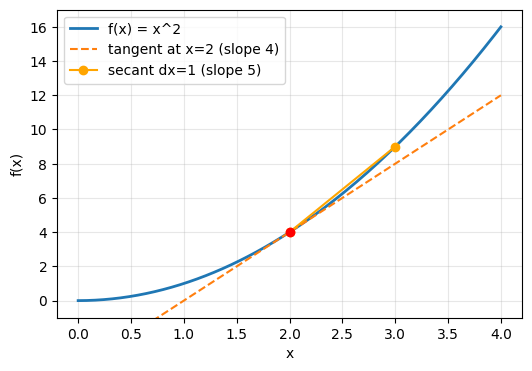

In [10]:
xs = np.linspace(0, 4, 200)                            # xs: (200,)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(xs, f(xs), lw=2, label="f(x) = x^2")
ax.plot(xs, f(x0) + true_slope * (xs - x0), "--", label=f"tangent at x=2 (slope {true_slope:.0f})")
ax.plot([x0, x0 + 1], [f(x0), f(x0 + 1)], "o-", color="orange", label="secant dx=1 (slope 5)")
ax.scatter([x0], [f(x0)], color="red", zorder=3)
ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.set_ylim(-1, 17); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## ขั้นที่ 4 · อนุพันธ์ของ activation functions (สไลด์ p.10-12)
ตอน backward propagation เราต้องรู้ $g'(z)$ ของทุก activation สไลด์พิสูจน์สูตรปิดไว้ให้แล้ว

| activation | $g'(z)$ | หน้าสไลด์ |
|---|---|---|
| sigmoid | $g(z)\,(1 - g(z))$ | p.10 |
| tanh | $1 - \tanh^2(z)$ | p.11 |
| ReLU | $0$ ถ้า $z < 0$, $1$ ถ้า $z > 0$, ไม่นิยามที่ $z = 0$ (ปฏิบัติใช้ 0) | p.12 |

สังเกตว่าสูตรของ sigmoid และ tanh **ใช้ค่า $g(z)$ ที่คำนวณไปแล้วตอน forward** — ไม่ต้องคำนวณ exp ใหม่ นี่คือเหตุผลที่ neural network เก็บ activation ไว้ (cache)

เราไม่ต้องไล่พิสูจน์ตาม แต่ตรวจได้ทันทีด้วย `nudge` จากขั้นที่ 3: ถ้าสูตรถูก `nudge(g, z)` กับสูตรปิดต้องใกล้กันทุกจุดบน grid
(ใช้ `atol=1e-3` เพราะ forward difference มี error ประมาณ $\Delta x$; grid เลือกให้ไม่มี $z = 0$ พอดีเพื่อเลี่ยงจุดที่ ReLU ไม่นิยาม)

In [11]:
def d_sigmoid(z):
    g = sigmoid(z)
    return g * (1.0 - g)                               # p.10

def d_tanh(z):
    return 1.0 - np.tanh(z) ** 2                       # p.11

def d_relu(z):
    return (np.asarray(z) > 0).astype(float)           # p.12: 1 ถ้า z > 0 ไม่งั้น 0

z_grid = np.linspace(-5, 5, 100)                       # z_grid: (100,) — ไม่มี 0.0 พอดี
for name, g, dg in [("sigmoid", sigmoid, d_sigmoid), ("tanh", tanh, d_tanh), ("relu", relu, d_relu)]:
    numeric = nudge(g, z_grid)                         # numeric: (100,)
    closed = dg(z_grid)                                # closed:  (100,)
    assert np.allclose(numeric, closed, atol=1e-3), name
    print(f"{name:8s} max |nudge - closed form| = {np.abs(numeric - closed).max():.2e}  ✓")

print("\nที่ z = 0: sigmoid'(0) =", d_sigmoid(0.0), "(= 0.5 × 0.5) | tanh'(0) =", d_tanh(0.0))
print("ค่าสูงสุดของ sigmoid' บน grid =", d_sigmoid(z_grid).max().round(4), "| ของ tanh' =", d_tanh(z_grid).max().round(4))

sigmoid  max |nudge - closed form| = 4.81e-05  ✓
tanh     max |nudge - closed form| = 3.85e-04  ✓
relu     max |nudge - closed form| = 3.34e-13  ✓

ที่ z = 0: sigmoid'(0) = 0.25 (= 0.5 × 0.5) | tanh'(0) = 1.0
ค่าสูงสุดของ sigmoid' บน grid = 0.2498 | ของ tanh' = 0.9975


วาด $g$ (บน) และ $g'$ (ล่าง) เรียงกัน — สิ่งที่อยากให้เห็น: ในโซน saturation ที่ $g$ แบน $g'$ จะเกือบเป็น 0
(นี่คือต้นเหตุของปัญหา "vanishing gradient" ที่จะเจอตอนเทรน network ลึกๆ) ส่วน ReLU มี $g' = 1$ คงที่ทางขวา จึงเป็นที่นิยมใน hidden layer
สังเกตด้วยว่า sigmoid' สูงสุดแค่ 0.25 ขณะที่ tanh' สูงสุด 1

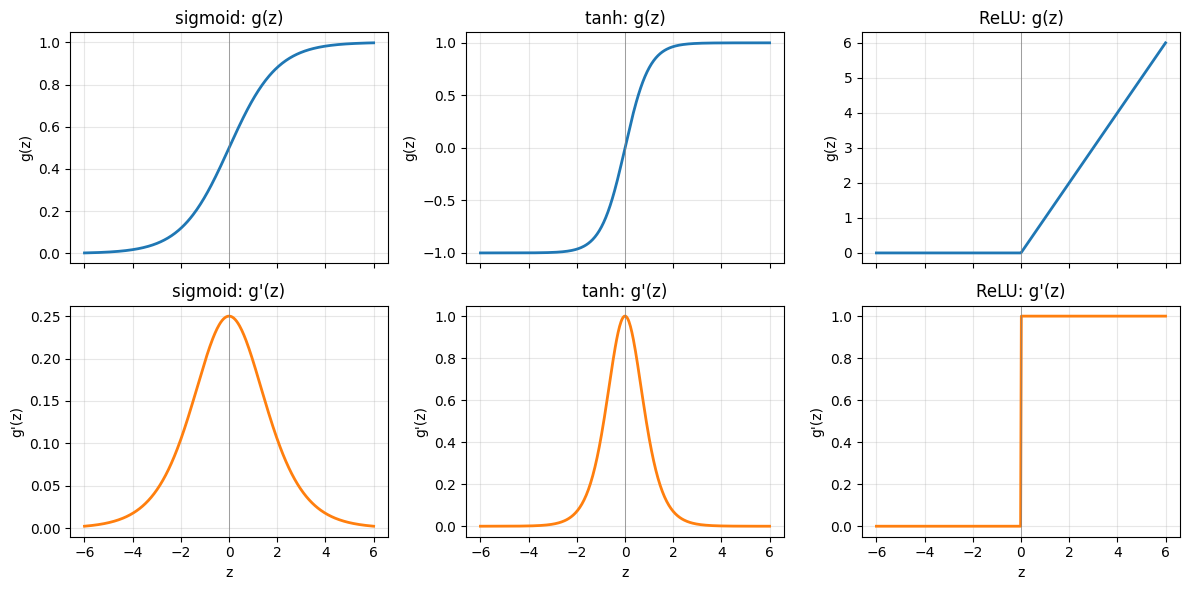

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
pairs = [("sigmoid", sigmoid, d_sigmoid), ("tanh", tanh, d_tanh), ("ReLU", relu, d_relu)]
for j, (name, g, dg) in enumerate(pairs):
    axes[0, j].plot(zs, g(zs), lw=2);  axes[0, j].set_title(f"{name}: g(z)");  axes[0, j].set_ylabel("g(z)")
    axes[1, j].plot(zs, dg(zs), lw=2, color="C1"); axes[1, j].set_title(f"{name}: g'(z)"); axes[1, j].set_ylabel("g'(z)")
    axes[1, j].set_xlabel("z")
    for ax in axes[:, j]:
        ax.grid(alpha=0.3); ax.axvline(0, color="gray", lw=0.5)
plt.tight_layout(); plt.show()

## ขั้นที่ 5 · computational graph และ chain rule (สไลด์ p.22-24)
neural network เป็น function ที่ซ้อนกันหลายชั้น การหาอนุพันธ์ตรงๆ ยุ่งมาก สไลด์จึงเสนอให้แตก function เป็น**ขั้นเล็กๆ** แล้ววาดเป็น graph
ตัวอย่าง p.22: $J(a, b, c) = 3(a + bc)$ แตกเป็น 3 ขั้น

```
a = 5 ─────────────────┐
                       (+) → v = 11 → (×3) → J = 33
b = 3 ─┐                │
       (×) → u = 6 ─────┘
c = 2 ─┘
```

- **forward path**: คำนวณจากซ้ายไปขวา $u = bc$, $v = a + u$, $J = 3v$ → ได้ค่า $J$
- **backward path**: หาว่า $J$ ไวต่อ $a$, $b$, $c$ แค่ไหน ($dJ/da$, $dJ/db$, $dJ/dc$) โดยเดินย้อนจากขวาไปซ้าย

cell นี้เขียน forward เป็นสามบรรทัดตรงตามสไลด์ — คาดว่าได้ 6, 11, 33

In [13]:
def forward(a, b, c):
    u = b * c            # ขั้น 1
    v = a + u            # ขั้น 2
    J = 3 * v            # ขั้น 3
    return u, v, J

a, b, c = 5.0, 3.0, 2.0
u, v, J = forward(a, b, c)
print(f"u = b × c = {b} × {c} = {u}")
print(f"v = a + u = {a} + {u} = {v}")
print(f"J = 3 × v = 3 × {v} = {J}")

u = b × c = 3.0 × 2.0 = 6.0
v = a + u = 5.0 + 6.0 = 11.0
J = 3 × v = 3 × 11.0 = 33.0


### backward ด้วยการ nudge (สไลด์ p.23-24)
ใช้เทคนิคเดียวกับขั้นที่ 3: ขยับตัวแปรทีละตัว 0.001 แล้วดูว่า $J$ เปลี่ยนเท่าไร
- p.23: ขยับ $v$ จาก 11 → 11.001 ได้ $J = 33.003$ ดังนั้น $dJ/dv = 0.003 / 0.001 = 3$
- p.24: ขยับ $a$ จาก 5 → 5.001 ทำให้ $v$ กลายเป็น 11.001 แล้ว $J = 33.003$ เช่นกัน ดังนั้น $dJ/da = 3$

จากนั้นทำแบบเดียวกันกับ $b$ และ $c$ — คาดว่าได้ 6 และ 9 (ทำไม? ดูคำอธิบาย chain rule ถัดไป)

In [14]:
dx = 1e-3

# p.23: nudge v ตรงๆ (v เป็นตัวแปรกลาง จึงคำนวณ J = 3v ใหม่ได้เลย)
J_v = 3 * (v + dx)
print(f"v = {v} → {v + dx:.3f}  ⇒  J = {J} → {J_v:.3f}  ⇒  dJ/dv = ({J_v:.3f} - {J}) / {dx} = {(J_v - J) / dx:.4f}")

# p.24: nudge a แล้วดูว่า v และ J เปลี่ยนอย่างไร
u_a, v_a, J_a = forward(a + dx, b, c)
print(f"a = {a} → {a + dx:.3f}  ⇒  v = {v} → {v_a:.3f}, J = {J} → {J_a:.3f}  ⇒  dJ/da = {(J_a - J) / dx:.4f}")

# ทำครบทุก input
grads_nudge = {}
for name, args in {"a": (a + dx, b, c), "b": (a, b + dx, c), "c": (a, b, c + dx)}.items():
    _, _, J_new = forward(*args)
    grads_nudge[name] = (J_new - J) / dx
    print(f"nudge {name}: J = {J_new:.3f}  ⇒  dJ/d{name} = {grads_nudge[name]:.4f}")

v = 11.0 → 11.001  ⇒  J = 33.0 → 33.003  ⇒  dJ/dv = (33.003 - 33.0) / 0.001 = 3.0000
a = 5.0 → 5.001  ⇒  v = 11.0 → 11.001, J = 33.0 → 33.003  ⇒  dJ/da = 3.0000
nudge a: J = 33.003  ⇒  dJ/da = 3.0000
nudge b: J = 33.006  ⇒  dJ/db = 6.0000
nudge c: J = 33.009  ⇒  dJ/dc = 9.0000


### chain rule: คูณความชันต่อกันตามเส้นทาง
ทำไม nudge $a$ แล้วได้ 3? เพราะ $a$ ส่งผลถึง $J$ ผ่าน $v$: ขยับ $a$ 0.001 → $v$ ขยับ 0.001 ($dv/da = 1$) → $J$ ขยับ 3 เท่าของนั้น ($dJ/dv = 3$)
สไลด์ p.24 เขียนเป็น
$$\frac{dJ}{da} = \frac{dJ}{dv}\cdot\frac{dv}{da} = 3 \times 1 = 3$$
นี่คือ **chain rule** — อนุพันธ์ของ function ซ้อนกัน = ผลคูณของอนุพันธ์แต่ละขั้นตามเส้นทางใน graph

เดินย้อนจาก $J$ ไปทีละขั้น (ความชันของแต่ละกล่อง: $\times 3$ ให้ 3, $+$ ให้ 1 ทั้งสองขา, $\times$ ให้ "อีกตัว")
1. $dJ/dv = 3$
2. $dJ/da = dJ/dv \cdot dv/da = 3 \cdot 1 = 3$ และ $dJ/du = dJ/dv \cdot dv/du = 3 \cdot 1 = 3$
3. $dJ/db = dJ/du \cdot du/db = 3 \cdot c = 3 \cdot 2 = 6$ และ $dJ/dc = dJ/du \cdot du/dc = 3 \cdot b = 3 \cdot 3 = 9$

cell นี้คำนวณตามลำดับนั้นแล้วเทียบกับผล nudge ด้วย `np.allclose` — ต้องตรงกันทุกตัว

In [15]:
# อนุพันธ์ของแต่ละกล่อง (local derivative)
dJ_dv = 3.0            # J = 3v
dv_da, dv_du = 1.0, 1.0   # v = a + u  → บวก: ส่งต่อความชันเท่าเดิม
du_db, du_dc = c, b       # u = b × c  → คูณ: อนุพันธ์เทียบ b คือ c และเทียบ c คือ b

# เดินย้อนจาก J (chain rule)
dJ_da = dJ_dv * dv_da
dJ_du = dJ_dv * dv_du
dJ_db = dJ_du * du_db
dJ_dc = dJ_du * du_dc
grads_chain = {"a": dJ_da, "b": dJ_db, "c": dJ_dc}

print(f"{'ตัวแปร':8s}{'chain rule':>12s}{'nudge':>12s}")
print(f"{'v':8s}{dJ_dv:12.4f}{(J_v - J) / dx:12.4f}")
print(f"{'u':8s}{dJ_du:12.4f}{'-':>12s}")
for k in ["a", "b", "c"]:
    print(f"{k:8s}{grads_chain[k]:12.4f}{grads_nudge[k]:12.4f}")
    assert np.allclose(grads_chain[k], grads_nudge[k])
print("\nสรุป: dJ/da = 3, dJ/db = 6, dJ/dc = 9 — ตรงกับสไลด์ p.24 และผล nudge ทุกตัว ✓")

ตัวแปร    chain rule       nudge
v             3.0000      3.0000
u             3.0000           -
a             3.0000      3.0000
b             6.0000      6.0000
c             9.0000      9.0000

สรุป: dJ/da = 3, dJ/db = 6, dJ/dc = 9 — ตรงกับสไลด์ p.24 และผล nudge ทุกตัว ✓


สังเกตว่า backward ใช้ค่าจาก forward ($b = 3$, $c = 2$) เป็นอนุพันธ์ของกล่องคูณ — จึงต้องทำ forward ก่อนเสมอ และเก็บค่ากลางไว้
ขั้นตอนทั้งหมดนี้ (สร้าง graph ตอน forward → เดินย้อนคูณ local derivative ตอน backward) คือสิ่งที่ **PyTorch autograd** ทำให้อัตโนมัติ
ใน lab04 เราจะเขียน `J.backward()` แล้วอ่าน `a.grad`, `b.grad`, `c.grad` ได้ 3, 6, 9 เหมือนกันเป๊ะ
และใน lab05-07 backward propagation ของ perceptron / neural network ก็คือ chain rule แบบนี้ ต่างแค่กล่องเยอะขึ้นและเป็น matrix

## ขั้นที่ 6 · เวอร์ชัน production ใน `nnlab`
โค้ดที่เราเพิ่งเขียนใน cell ด้านบนคือ "โค้ดเพื่อความเข้าใจ" — แยกทุกขั้นให้เห็น
ในการใช้งานจริง โค้ดเดียวกันถูกจัดเป็นฟังก์ชัน/คลาสใน `src/nnlab/activations.py` พร้อม docstring, type hints และ test
cell ถัดไปเรียกเวอร์ชัน production มาเทียบกับที่เราเขียนเอง (sigmoid/tanh/relu, derivatives และ numerical_derivative) — ตัวเลขต้องตรงกัน
เปิดไฟล์ `src/nnlab/activations.py` ควบคู่กันเพื่อดูว่าโค้ด "ทดลอง" กลายเป็นโค้ด "ใช้งานจริง" ได้อย่างไร

In [16]:
from nnlab import activations as act

# activation และอนุพันธ์ต้องตรงกับที่เราเขียนเองทุกจุดบน grid
for name, mine, theirs in [("sigmoid", sigmoid, act.sigmoid), ("d_sigmoid", d_sigmoid, act.d_sigmoid),
                           ("tanh", tanh, act.tanh), ("d_tanh", d_tanh, act.d_tanh),
                           ("relu", relu, act.relu), ("d_relu", d_relu, act.d_relu)]:
    assert np.allclose(mine(z_grid), theirs(z_grid)), name
    print(f"{name:10s} ตรงกับ nnlab ✓")

# nnlab.sigmoid ก็ stable เหมือนกัน (ใช้ mask แยกกรณี z < 0 แทน np.where — อ่าน docstring ในไฟล์)
print("\nact.sigmoid([-1000, 0, 1000]) =", act.sigmoid(np.array([-1000.0, 0.0, 1000.0])))

# numerical_derivative = nudge ของเรา และมี method='central' ที่แม่นกว่า
print("numerical_derivative(x², 2) forward =", act.numerical_derivative(f, np.array(2.0)),
      "| central =", act.numerical_derivative(f, np.array(2.0), method="central"))
assert np.isclose(act.numerical_derivative(f, np.array(2.0)), nudge(f, 2.0))

sigmoid    ตรงกับ nnlab ✓
d_sigmoid  ตรงกับ nnlab ✓
tanh       ตรงกับ nnlab ✓
d_tanh     ตรงกับ nnlab ✓
relu       ตรงกับ nnlab ✓
d_relu     ตรงกับ nnlab ✓

act.sigmoid([-1000, 0, 1000]) = [0.  0.5 1. ]
numerical_derivative(x², 2) forward = 4.000999999999699 | central = 3.9999999999995595


## ★ Key Takeaways
- function = หนึ่ง input → หนึ่ง output; neural network ทั้งก้อนคือ function ตัวเดียว และ numpy ทำให้ function รับ array ทั้งก้อนได้
- sigmoid ให้ (0,1), tanh ให้ (-1,1), ReLU = max(0, z); สองตัวแรก saturate เมื่อ |z| > 4 และ |z| > 2 — ตรงนั้น g' ≈ 0
- อนุพันธ์คือความชัน หาได้โดยไม่ต้องรู้แคลคูลัส: nudge x ด้วย Δx เล็กๆ แล้วหาร Δf/Δx (p.9: 0.004/0.001 = 4) ยิ่ง Δx เล็ก ยิ่งใกล้ค่าจริง
- สูตรปิด g' = g(1−g), 1−tanh², step ตรวจสอบได้ด้วย nudge และใช้ค่า g จาก forward ซ้ำได้ — ไม่ต้องคำนวณ exp ใหม่
- computational graph แตก function ใหญ่เป็นกล่องเล็ก; forward คำนวณซ้ายไปขวา, backward คูณ local derivative ย้อนกลับ (chain rule) ได้ 3, 6, 9
- เขียน sigmoid ให้ stable ด้วย exp(−|z|) เพื่อเลี่ยง overflow; nnlab.activations มีเวอร์ชันนี้พร้อม numerical_derivative ให้ใช้

## แบบฝึกหัด (ทำเอง)
ส่วนนี้ต้อง**เขียนโค้ดเอง** — แต่ละข้อมี 3 cell: โจทย์ (อ่านให้จบก่อน) → cell โครง (มี `raise NotImplementedError` ให้แทนที่ด้วยโค้ดของคุณ) → cell ตรวจคำตอบ
cell ตรวจคำตอบรันได้ทันที: ถ้ายังไม่ได้ทำจะขึ้น ⏳ ถ้าผิดจะขึ้น ✗ พร้อมคำใบ้ ถ้าถูกจะขึ้น ✓ PASS
ทำได้ไม่จำกัดรอบ แก้แล้วรัน cell โครงและ cell ตรวจซ้ำ ใช้ผลจาก cell ก่อนหน้าใน lab นี้ได้ทุกตัว

In [17]:
from nnlab.exercise import check, check_close, check_shape, summary, reset
reset()   # ล้างผลการตรวจเก่าใน kernel นี้

### แบบฝึกหัด 2.1 · อนุพันธ์ของ sigmoid ที่ z = 0 สองวิธี
**เป้าหมาย:** ยืนยันด้วยตัวเลขว่า sigmoid'(0) = 0.25 ทั้งจากการ nudge (ขั้นที่ 3) และจากสูตรปิด g(1−g) (สไลด์ p.10) แล้วดูว่าลด Δx แล้วแม่นขึ้นจริง

**ขั้นตอน**
1. กำหนด `slope_nudge` = ความชันของ `sigmoid` ที่ 0.0 ด้วยฟังก์ชัน `nudge` (Δx ค่าเริ่มต้น 1e-3)
2. กำหนด `slope_closed` = ค่าจากสูตรปิด g(1−g) ที่ z = 0 โดยใช้ `d_sigmoid` จากขั้นที่ 4
3. กำหนด `slope_nudge_small` = nudge อีกครั้งแต่ส่ง `dx=1e-6` — ควรใกล้ 0.25 มากกว่า `slope_nudge`
4. รัน cell แล้วดูว่าสามค่าต่างกันตรงทศนิยมหลักไหน

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `nudge(sigmoid, 0.0)` คืนความชันที่จุด 0.0; ค่าที่ได้ควรเป็น 0.24999997... ไม่ใช่ 0.25 เป๊ะ
- `d_sigmoid(0.0)` ใช้สูตรปิด จึงได้ 0.25 เป๊ะ
- `nudge(sigmoid, 0.0, dx=1e-6)` — Δx เล็กลง 1000 เท่า error ลดลงตาม (ดูตารางในขั้นที่ 3)
</details>

In [18]:
# --- แบบฝึกหัด 2.1: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
slope_nudge = ...              # TODO: ความชันของ sigmoid ที่ 0.0 จาก nudge (Δx = 1e-3)   ← แทน ... ด้วยโค้ดของคุณ
slope_closed = ...             # TODO: สูตรปิด g(1-g) ที่ z = 0
slope_nudge_small = ...        # TODO: nudge อีกครั้งด้วย dx=1e-6
print(f"nudge dx=1e-3 : {slope_nudge}")
print(f"closed form   : {slope_closed}")
print(f"nudge dx=1e-6 : {slope_nudge_small}")

nudge dx=1e-3 : Ellipsis
closed form   : Ellipsis
nudge dx=1e-6 : Ellipsis


In [19]:
# --- ตรวจคำตอบ 2.1 (รันได้ทันที ไม่ต้องแก้) ---
# เทียบกับค่าที่รู้จากสไลด์ p.10: sigmoid'(0) = 0.5 × 0.5 = 0.25  (rtol=0 เพื่อวัดความแม่นจริงๆ)
check_close("2.1 nudge dx=1e-3 ≈ 0.25", lambda: slope_nudge, 0.25, atol=1e-4, rtol=0, hint="nudge(ฟังก์ชัน, จุด) — ส่ง sigmoid เข้าไปเป็น argument แรก ไม่ต้องเรียก sigmoid เอง")
check_close("2.1 สูตรปิดได้ 0.25 พอดี", lambda: slope_closed, 0.25, atol=1e-12, rtol=0, hint="d_sigmoid(0.0) = g(0)(1 - g(0)) = 0.5 × 0.5")
check_close("2.1 nudge dx=1e-6 คลาดจาก 0.25 ไม่เกิน 1e-8", lambda: slope_nudge_small, 0.25, atol=1e-8, rtol=0, hint="nudge รับ dx เป็น argument ที่สาม — ถ้ายังใช้ 1e-3 error จะอยู่ราว 2e-8 ซึ่งเกินเกณฑ์")

⏳ 2.1 nudge dx=1e-3 ≈ 0.25: ยังไม่ได้ทำ
⏳ 2.1 สูตรปิดได้ 0.25 พอดี: ยังไม่ได้ทำ
⏳ 2.1 nudge dx=1e-6 คลาดจาก 0.25 ไม่เกิน 1e-8: ยังไม่ได้ทำ


False

### แบบฝึกหัด 2.2 · Leaky ReLU และอนุพันธ์ด้วย nudge
**เป้าหมาย:** เขียน activation ตัวใหม่ `leaky_relu(z, alpha=0.01)` ที่คืน z เมื่อ z > 0 และ alpha·z เมื่อ z ≤ 0 แล้วใช้ `nudge` หาความชันบน `z_grid` — ควรได้ 1 ทางขวาและ 0.01 ทางซ้าย (ReLU ธรรมดาได้ 0 ทางซ้าย ทำให้ neuron "ตาย" ได้ Leaky ReLU แก้ตรงนี้)

**ขั้นตอน**
1. เขียนตัวฟังก์ชันด้วย `np.where(เงื่อนไข, ค่าเมื่อจริง, ค่าเมื่อเท็จ)` บรรทัดเดียว (แบบเดียวกับ `sigmoid` ตัว stable ในขั้นที่ 2) — ต้องรับ array ทั้งก้อนได้ และต้องใช้ตัวแปร `alpha` ไม่ hardcode 0.01
2. กำหนด `slope_grid` = อนุพันธ์เชิงตัวเลขของ `leaky_relu` บน `z_grid` (100 จุด ไม่มี 0 พอดี) ด้วย `nudge` จากขั้นที่ 3
3. พิมพ์ `slope_grid[:3]` และ `slope_grid[-3:]` — คาดว่า 0.01 ทางซ้ายและ 1.0 ทางขวา

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `np.where(z > 0, z, alpha * z)` — ทำงานทีละตัวกับ array ทั้งก้อน
- `nudge(leaky_relu, z_grid)` — nudge รับฟังก์ชันเป็น argument แรก และคืน array ถ้า x เป็น array
</details>

In [20]:
# --- แบบฝึกหัด 2.2: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def leaky_relu(z, alpha=0.01):
    """z ถ้า z > 0, alpha * z ถ้า z <= 0   (รับ array ได้: z (n,) → (n,))"""
    raise NotImplementedError("ยังไม่ได้ทำ")

slope_grid = ...               # TODO: ความชันของ leaky_relu ทุกจุดบน z_grid → (100,)
# print(slope_grid[:3], slope_grid[-3:])

In [21]:
# --- ตรวจคำตอบ 2.2 (รันได้ทันที ไม่ต้องแก้) ---
z_pts = np.array([-2.0, -1.0, 0.5, 3.0])
check_close("2.2 leaky_relu ที่ z = [-2, -1, 0.5, 3]", lambda: leaky_relu(z_pts), [-0.02, -0.01, 0.5, 3.0], hint="ฝั่งลบต้องได้ alpha × z (ติดลบเล็กน้อย) ไม่ใช่ 0")
check_close("2.2 ฝั่งบวกเท่ากับ relu", lambda: leaky_relu(z_grid)[z_grid > 0], relu(z_grid)[z_grid > 0], hint="เมื่อ z > 0 ต้องคืน z เดิม")
check_close("2.2 alpha เปลี่ยนได้: leaky_relu(-1, alpha=0.2) = -0.2", lambda: leaky_relu(-1.0, alpha=0.2), -0.2, hint="ใช้ตัวแปร alpha ในตัวฟังก์ชัน ไม่ใช่ตัวเลข 0.01")
check_shape("2.2 slope_grid shape (100,)", lambda: slope_grid, (100,), hint="nudge รับ array เป็น x ได้ → คืน array ขนาดเท่ากัน")
ref_slope = [1.0 if zz > 0 else 0.01 for zz in z_grid]      # loop ทีละจุด (คนละวิธีกับ np.where)
check_close("2.2 ความชัน 1 ทางขวา 0.01 ทางซ้าย", lambda: slope_grid, ref_slope, atol=1e-4, rtol=0, hint="ถ้าฝั่งซ้ายได้ 0 แสดงว่าฟังก์ชันยังเป็น relu ธรรมดา; ถ้าไม่ตรงเลย ตรวจว่าใช้ nudge กับ leaky_relu (ไม่ใช่ relu)")

⏳ 2.2 leaky_relu ที่ z = [-2, -1, 0.5, 3]: ยังไม่ได้ทำ
⏳ 2.2 ฝั่งบวกเท่ากับ relu: ยังไม่ได้ทำ
⏳ 2.2 alpha เปลี่ยนได้: leaky_relu(-1, alpha=0.2) = -0.2: ยังไม่ได้ทำ
⏳ 2.2 slope_grid shape (100,): ยังไม่ได้ทำ
⏳ 2.2 ความชัน 1 ทางขวา 0.01 ทางซ้าย: ยังไม่ได้ทำ


False

### แบบฝึกหัด 2.3 · computational graph ใหม่: J = (a + b)(b − c)
**เป้าหมาย:** สร้าง graph ของ $J = (a + b)(b - c)$ โดยแตกเป็น p = a + b, q = b − c, J = p × q แล้วหา dJ/da, dJ/db, dJ/dc ด้วยการ nudge และด้วย chain rule — คราวนี้ b เข้าไป**สองทาง** ต้องบวกผลจากทั้งสองเส้นทาง

**ขั้นตอน**
1. เขียน `forward2(a, b, c)` คืน `(p, q, J)` ตามสามขั้นข้างบน (แบบเดียวกับ `forward` ในขั้นที่ 5)
2. เขียน `grads_nudge2(a, b, c, dx=1e-3)` ที่ nudge ทีละตัวแปรแล้วคืน dict `{"a": dJ/da, "b": dJ/db, "c": dJ/dc}` (ทำซ้ำ loop ในขั้นที่ 5 แต่เรียก `forward2` และใช้ J ที่คืนมาตัวสุดท้าย)
3. เดิน chain rule ด้วยมือที่ a=2, b=5, c=1 (p = 7, q = 4): local derivative ของกล่องคูณคือ "อีกตัว" (dJ/dp = q, dJ/dq = p) กล่องบวกให้ 1 กล่องลบให้ 1 และ −1; b ส่งผลถึง J ผ่านทั้ง p และ q จึงต้อง**บวก**สองเส้นทาง — เติมตัวเลขใน `dJ_da_chain`, `dJ_db_chain`, `dJ_dc_chain`
4. รัน cell ตรวจ: chain rule กับ nudge ต้องตรงกัน (ต่างกันไม่เกิน 0.01)

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- forward2: `p = a + b; q = b - c; J = p * q; return p, q, J`
- grads_nudge2: `J0 = forward2(a, b, c)[2]` แล้วสำหรับ a: `(forward2(a + dx, b, c)[2] - J0) / dx` ทำแบบเดียวกันกับ b และ c
- chain rule: dJ/da = q × 1, dJ/db = q × 1 + p × 1, dJ/dc = p × (−1) — แทน p = 7, q = 4
</details>

In [22]:
# --- แบบฝึกหัด 2.3: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def forward2(a, b, c):
    """คืน (p, q, J) โดย p = a + b, q = b - c, J = p * q"""
    raise NotImplementedError("ยังไม่ได้ทำ")

def grads_nudge2(a, b, c, dx=1e-3):
    """คืน dict {"a": dJ/da, "b": dJ/db, "c": dJ/dc} จากการ nudge ทีละตัวแปร (ใช้ forward2)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# chain rule ด้วยมือที่ a=2, b=5, c=1 (p = 7, q = 4) — เติมเป็นตัวเลขหรือนิพจน์ก็ได้
dJ_da_chain = ...              # TODO: dJ/dp × dp/da
dJ_db_chain = ...              # TODO: dJ/dp × dp/db + dJ/dq × dq/db   (สองเส้นทาง)
dJ_dc_chain = ...              # TODO: dJ/dq × dq/dc
# print(forward2(2.0, 5.0, 1.0), grads_nudge2(2.0, 5.0, 1.0))

In [23]:
# --- ตรวจคำตอบ 2.3 (รันได้ทันที ไม่ต้องแก้) ---
# อ้างอิงคนละวิธี: central difference ของ nnlab บนสูตร J ตรงๆ (ไม่ผ่าน graph ที่นิสิตเขียน)
J_ref = lambda a, b, c: (a + b) * (b - c)
def ref_grads(a, b, c):
    return [float(act.numerical_derivative(lambda x: J_ref(x, b, c), np.array(a), method="central")),
            float(act.numerical_derivative(lambda x: J_ref(a, x, c), np.array(b), method="central")),
            float(act.numerical_derivative(lambda x: J_ref(a, b, x), np.array(c), method="central"))]
check_close("2.3 forward2(2, 5, 1) = (7, 4, 28)", lambda: forward2(2.0, 5.0, 1.0), [7, 4, 28], hint="p = a + b, q = b - c, J = p * q แล้ว return p, q, J ตามลำดับ")
check_close("2.3 nudge ที่ (2, 5, 1)", lambda: [grads_nudge2(2.0, 5.0, 1.0)[k] for k in "abc"], ref_grads(2.0, 5.0, 1.0), atol=1e-2, rtol=0, hint="nudge ตัวแปรละครั้ง: (J(a+dx, b, c) - J) / dx เป็นต้น — J เอาจาก forward2(...)[2]")
check_close("2.3 nudge ใช้ได้กับจุดอื่น (1, 2, 3)", lambda: [grads_nudge2(1.0, 2.0, 3.0)[k] for k in "abc"], ref_grads(1.0, 2.0, 3.0), atol=1e-2, rtol=0, hint="อย่า hardcode ตัวเลข ให้คำนวณจาก a, b, c ที่รับเข้ามา")
ref_a, ref_b, ref_c = ref_grads(2.0, 5.0, 1.0)
check_close("2.3 chain rule dJ/da", lambda: dJ_da_chain, ref_a, hint="dJ/dp คือค่าของ q (อีกตัวของกล่องคูณ) และ dp/da = 1")
check_close("2.3 chain rule dJ/db (สองเส้นทาง)", lambda: dJ_db_chain, ref_b, hint="เส้นทางผ่าน p ให้ q × 1, เส้นทางผ่าน q ให้ p × 1 — ต้องบวกกัน")
check_close("2.3 chain rule dJ/dc", lambda: dJ_dc_chain, ref_c, hint="dq/dc = -1 (c ถูกลบ) จึงติดลบ")

⏳ 2.3 forward2(2, 5, 1) = (7, 4, 28): ยังไม่ได้ทำ
⏳ 2.3 nudge ที่ (2, 5, 1): ยังไม่ได้ทำ
⏳ 2.3 nudge ใช้ได้กับจุดอื่น (1, 2, 3): ยังไม่ได้ทำ
⏳ 2.3 chain rule dJ/da: ยังไม่ได้ทำ
⏳ 2.3 chain rule dJ/db (สองเส้นทาง): ยังไม่ได้ทำ
⏳ 2.3 chain rule dJ/dc: ยังไม่ได้ทำ


False

### สรุปผลแบบฝึกหัด
รัน cell นี้หลังทำครบทุกข้อ (รัน cell ตรวจของทุกข้อก่อน)

In [24]:
summary()

สรุป: PASS 0/14 · FAIL 0 · ยังไม่ได้ทำ 14


{'pass': 0, 'fail': 0, 'todo': 14, 'error': 0}